In [1]:
!nvidia-smi

Tue Mar 17 15:25:14 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 575.57.08              Driver Version: 575.57.08      CUDA Version: 12.9     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100 80GB PCIe          On  |   00000000:19:00.0 Off |                   On |
| N/A   63C    P0            265W /  300W |   37121MiB /  81920MiB |     N/A      Default |
|                                         |                        |              Enabled |
+-----------------------------------------+-----

In [2]:
import os
import numpy as np
import xarray as xr
import pickle
import glob
import warnings
from pathlib import Path, PureWindowsPath
import re

import cedalion
import cedalion.sigproc.motion as motion_correct
import cedalion.sigproc.quality as quality
import cedalion.sigproc.physio as physio
import cedalion.dot as dot
import cedalion.nirs as nirs
from cedalion.io.forward_model import load_Adot
from cedalion import units
import copy
from matplotlib import pyplot as plt

warnings.filterwarnings("ignore")

In [3]:
base_path = "/home/orabe/fNIRS_sparseToDense/"

# Available datasets:
# DATASET_NAME = "BallSqueezingHD_modified"
# DATASET_NAME = "FreshMotor"
DATASET_NAME = "BS_Laura"
# DATASET_NAME = "ElectricalThermal"

raw_path = Path(f'datasets/raw/{DATASET_NAME}')

pre_processed_path = Path(f'datasets/pre_processed/{DATASET_NAME}/full')
pre_processed_path.mkdir(parents=True, exist_ok=True)

In [4]:
if DATASET_NAME == "BallSqueezingHD_modified":
    raw_dir = f"{raw_path}/sub-*/nirs/sub-*.snirf"

elif DATASET_NAME == "BS_Laura":
    raw_dir = f"{raw_path}/sub-*/nirs/sub-*.snirf"
    
elif DATASET_NAME == "Electrical_Thermal":
    raw_dir = f"{raw_path}/sub-*/ses-*/nirs/sub-*_ses-*_task-Electrical*_nirs.snirf"
    # TODO: exclude subjects without txt files for landmarks coords
    
elif DATASET_NAME == "FreshMotor":
    duration = "*" # * to include both 2s and 3s
    raw_dir = f"{raw_path}/sub-*/ses-*{duration}/nirs/sub-*_ses-*{duration}_task-FRESHMOTOR_nirs.snirf"
else:
    raise ValueError("Unknown dataset name")

files = glob.glob(raw_dir)

# TODO: to be confirmed
# remove non-BS files for Laura's dataset to avoid errors
if DATASET_NAME == "BS_Laura":
    files = [p for p in files if "BS" in os.path.basename(p)]
    
    # remove files that has this pattern in the name: _acq-4NN_nirs:
    files = [p for p in files if "_acq-4NN_nirs" not in os.path.basename(p)]
    
files = sorted(files)
print(f"{len(files)} files found.")

57 files found.


In [5]:
filename = files[1] # select one
rec = cedalion.io.read_snirf(filename)[0]  # read snirf files
rec['amp']

Magnitude,[[[0.0021773733195343315 0.002159860588358232 0.002144665718661322 ... 0.0018875118645534468 0.0018545467235160827 0.0018032962308095557] [0.002821738810749057 0.002818648328776804 0.002830108866090575 ... 0.002711125310158839 0.002662063908849325 0.0025994816489112037]] [[0.00031007835788270566 0.00026127449673754555 0.00026758423076422855 ... 0.0002607594164088368 0.00029449717793926403 0.0002686143914216462] [0.000594016389083439 0.0005817832312766047 0.0005707090042093651 ... 0.0005561579849233413 0.0005803667603726555 0.0005811393808657187]] [[0.11490605127959475 0.11484475672047839 0.11499593279695443 ... 0.11423992364449208 0.11458167944259037 0.11514337454104734] [0.15292065354937348 0.15316261253378444 0.15364395510096285 ... 0.151739445585562 0.15230461747623772 0.1533328465824227]] ... [[0.00011254505182287572 0.00025277567131385016 0.00023036967701501676 ... 0.00022882443602889035 0.00020551705115481655 0.00024981395942377446] [0.00041026148181656986 0.000512376156983092 0.00048739476104071465 ... 0.0004861070602189426 0.0004956360463000556 0.0005094144450930164]] [[0.5536388558057087 0.5513941357331956 0.5492584839202866 ... 0.4652017524578024 0.4541924255119802 0.44467670274933135] [0.7458432695547994 0.7425284700993938 0.739191007109525 ... 0.6135644601784316 0.5979334462131873 0.5854578143416134]] [[1e-06 3.8631024653160986e-06 1e-06 ... 1e-06 1e-06 9.271445916758637e-06] [1e-06 7.211124601923366e-06 1.5452409861264394e-06 ... 7.726204930632197e-07 1e-06 1.1074227067239465e-05]]]
Units,dimensionless


In [6]:
filename

'datasets/raw/BS_Laura/sub-538/nirs/sub-538_task-BS_run-02_nirs.snirf'

In [7]:
filename = files[0] # select one
rec = cedalion.io.read_snirf(filename)[0]  # read snirf files

In [8]:
# TODO: shakiba's
# ds_ch, chd_mask = quality.sd_dist(rec["amp"], rec.geo3d, [1, 4.5]*units.cm)
# rec['amp'] = rec['amp'].sel(channel=chd_mask)
# meas_list = rec._measurement_lists["amp"]
# meas_list

In [9]:
# filename = files[0] # select one
# rec = cedalion.io.read_snirf(filename)[0]  # read snirf files

meas_list = rec._measurement_lists["amp"]

head_icbm152 = dot.get_standard_headmodel('icbm152')  

if DATASET_NAME == "BS_Laura":
    # this is required for BU Data (Laura's)
    T = np.array([
        [-9.57882733e-01, -7.20806358e-03,  6.20193531e-03, 2.21208571e+02],
        [-2.02271710e-02,  6.03819925e-02,  9.94046165e-01, -2.03010603e+01],
        [-8.79481533e-03, -1.02761992e+00,  6.59199998e-02, 2.87749135e+02],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, 1.00000000e+00]])
    
    print("Applying transformation for Laura's data")
    ninja_aligned = rec.geo3d.points.apply_transform(T)
    geo3d_snapped_ijk = head_icbm152.align_and_snap_to_scalp(ninja_aligned)
else:
    geo3d_snapped_ijk = head_icbm152.align_and_snap_to_scalp(rec.geo3d)

fwm = cedalion.dot.forward_model.ForwardModel(
    head_icbm152, 
    geo3d_snapped_ijk,
    meas_list
)

fluence_fname = os.path.join(pre_processed_path, "fluence_" + DATASET_NAME + ".h5")
sensitivity_fname = os.path.join(pre_processed_path, "sensitivity_" + DATASET_NAME + ".h5")

# compute fluence and sensitivity only once
# fwm.compute_fluence_mcx(fluence_fname)
# fwm.compute_sensitivity(fluence_fname, sensitivity_fname)

Adot = load_Adot(sensitivity_fname)

Applying transformation for Laura's data


In [10]:
# from cedalion.vis.anatomy import plot_montage3D

# # use the plot_montage3D() function. It requires a recording container and a geo3d object
# plot_montage3D(rec["amp"], rec.geo3d)

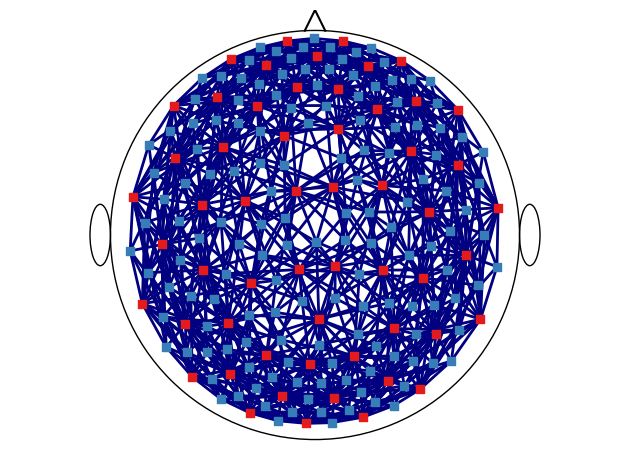

In [12]:
from cedalion.vis.anatomy import plot_montage3D

fig, ax = plt.subplots(1, 1)

cedalion.vis.anatomy.scalp_plot(
    rec['amp'],
    # geo3d_snapped_ijk,
    ninja_aligned,
    np.ones(rec['amp'].channel.size),
    ax,
    cmap="jet",
    title="",
    vmin=1,
    vmax=1,
    cb_label="",
    add_colorbar=False,
)
plt.tight_layout()

In [13]:
rec['amp'].shape

(1220, 2, 3241)

In [14]:
# build sensitivity once
parcel_dOD, parcel_mask = fwm.parcel_sensitivity(
    Adot,
    [],  # bad channels list
    dOD_thresh=0.001,
    minCh=1,
    dHbO=10,
    dHbR=-3
)

In [15]:
parcel_dOD.shape, parcel_mask.shape

((2, 1220, 602), (602,))

In [16]:
sens_parcel_yuanyuan_path = 'datasets/pre_processed/BallSqueezingHD_modified/parcel_template_BallSqueezingHD_modified.pkl'

with open(sens_parcel_yuanyuan_path, 'rb') as handle:
    template_sens_parcel_list = pickle.load(handle)

len(template_sens_parcel_list)

110

In [17]:
# Keep only motor parcels in the template list
template_sens_parcel_list = [l for l in template_sens_parcel_list if l.startswith("SomMot")]
len(template_sens_parcel_list)

47

In [18]:
# keep only parcels that passed the mask
valid_parcels = parcel_mask.where(parcel_mask, drop=True).parcel
parcel_dOD_valid = parcel_dOD.sel(parcel=valid_parcels)
parcel_dOD_valid.shape

(2, 1220, 374)

In [19]:
# keep only parcels that are in the template list from Yuanyuan dataset (bsq-hd)
parcel_dOD_valid = parcel_dOD.sel(parcel=template_sens_parcel_list)
parcel_dOD_valid.shape

(2, 1220, 47)

In [20]:
parcel_dOD_valid

<xarray.DataArray (wavelength: 2, channel: 1220, parcel: 47)> Size: 917kB
array([[[1.76686917e-12, 2.89169809e-16, 1.11249843e-14, ...,
         5.80012416e-16, 5.82167542e-12, 3.96382149e-18],
        [4.52627645e-11, 1.32880479e-12, 4.29264150e-11, ...,
         1.34152244e-14, 8.78606235e-16, 2.02550321e-16],
        [4.24664981e-13, 1.29237559e-14, 3.85998063e-13, ...,
         8.66935398e-16, 8.37886505e-18, 1.32155190e-17],
        ...,
        [2.39610859e-06, 8.01189068e-08, 2.71978165e-06, ...,
         4.71852142e-13, 1.24393026e-13, 4.31685859e-14],
        [1.86305417e-07, 1.90616155e-09, 4.99493129e-08, ...,
         1.10566638e-13, 2.61291151e-14, 1.92101333e-15],
        [6.35021332e-07, 3.76755892e-08, 1.29053063e-06, ...,
         2.52581438e-11, 2.39331601e-14, 4.96280923e-13]],

       [[1.23753004e-11, 2.02536968e-15, 7.79203266e-14, ...,
         4.06245579e-15, 4.07755048e-11, 2.77629394e-17],
        [3.17024213e-10, 9.30706061e-12, 3.00660225e-10, ...,
         9.39613609e-14, 6.15383204e-15, 1.41867950e-15],
        [2.97438928e-12, 9.05190740e-14, 2.70356293e-12, ...,
         6.07208851e-15, 5.86862762e-17, 9.25626078e-17],
        ...,
        [1.67825463e-05, 5.61159569e-07, 1.90495797e-05, ...,
         3.30489213e-12, 8.71259225e-13, 3.02356410e-13],
        [1.30489883e-06, 1.33509160e-08, 3.49849193e-07, ...,
         7.74418042e-13, 1.83010522e-13, 1.34549391e-14],
        [4.44774287e-06, 2.63882999e-07, 9.03898519e-06, ...,
         1.76910166e-10, 1.67629868e-13, 3.47599337e-12]]],
      shape=(2, 1220, 47))
Coordinates:
  * channel     (channel) object 10kB 'S1D2' 'S1D33' ... 'S56D134' 'S56D135'
  * parcel      (parcel) object 376B 'SomMotA_10_LH' ... 'SomMotB_S2_8_RH'
  * wavelength  (wavelength) float64 16B 760.0 850.0

In [19]:
# # Approach 1

# # parcel_dOD dims: (wavelength, channel, parcel)

# # reduce sensitivity across wavelength and parcel
# sens_strength = np.abs(parcel_dOD_valid).mean(dim="wavelength").max(dim="parcel")

# # keep top 10% sensitivity channels
# keep_ch = sens_strength > sens_strength.quantile(0.95)
# keep_channels = sens_strength.channel.values[keep_ch]

# rec_sub = copy.deepcopy(rec)

# rec_sub["amp"] = rec["amp"].sel(channel=keep_channels)

# # map to optodes (sources + detectors)
# keep_sources = set(rec["amp"].source.sel(channel=keep_channels).values)
# keep_detectors = set(rec["amp"].detector.sel(channel=keep_channels).values)
# keep_optodes = list(keep_sources | keep_detectors)

# rec_sub.geo3d = rec_sub.geo3d.sel(label=keep_optodes)

# print("Kept channels:", len(rec_sub['amp'].channel))
# print("Kept optodes:", len(rec_sub.geo3d.label))
# print("Kept sources:", len(set(rec_sub['amp'].source.values)))
# print("Kept detectors:", len(set(rec_sub['amp'].detector.values)))

# plot_montage3D(rec_sub['amp'], rec_sub.geo3d)

# fig, ax = plt.subplots(1, 1)
# cedalion.vis.anatomy.scalp_plot(
#     rec_sub['amp'],
#     geo3d_snapped_ijk,
#     np.ones(rec_sub['amp'].channel.size),
#     ax,
#     cmap="jet",
#     title="",
#     vmin=1,
#     vmax=1,
#     cb_label="",
#     add_colorbar=False,
# )
# plt.tight_layout()

In [20]:
# # Approach 2

# # parcel_dOD dims: (wavelength, channel, parcel)
# sens_strength = np.abs(parcel_dOD_valid).mean(dim="wavelength").max(dim="parcel")

# # sort channels by sensitivity
# sorted_idx = np.argsort(sens_strength.values)[::-1]
# sorted_channels = sens_strength.channel.values[sorted_idx]
# sorted_weights = sens_strength.values[sorted_idx]

# # top N channels
# N = 100
# top_channels = sorted_channels[:N]
# top_weights = sorted_weights[:N]

# print(top_channels)

# plot after subsetting channels
# rec_sub = copy.deepcopy(rec)
# rec_sub['amp'] = rec['amp'].sel(channel=top_channels)

# plot_montage3D(rec_sub['amp'], rec_sub.geo3d)


# fig, ax = plt.subplots(1, 1)

# cedalion.vis.anatomy.scalp_plot(
#     rec_sub['amp'],
#     geo3d_snapped_ijk,
#     np.ones(rec_sub['amp'].channel.size),
#     ax,
#     cmap="jet",
#     title="",
#     vmin=1,
#     vmax=1,
#     cb_label="",
#     add_colorbar=False,
# )
# plt.tight_layout()


In [21]:



min_d, max_d = 1, 4.5
# distance filtering
ds_ch, chd_mask = quality.sd_dist(rec["amp"], rec.geo3d, [min_d, max_d]*units.cm)
print(f"Channels before sd dist filtering: {rec['amp'].channel.size}")
print(f"Channels after sd dist filtering: {chd_mask.sum().item()}")
# ch_in = rec["amp_k"].channel.isin(chd_mask)
# rec["amp_k_dist"] = rec["amp_k"].sel(channel=chd_mask)

# # print number of channels after sd dist filtering
# print(f"Channels after sd dist filtering: {rec['amp_k_dist'].channel.size}")


Channels before sd dist filtering: 1220
Channels after sd dist filtering: 580


In [22]:
parcel_dOD_valid.sel(channel=chd_mask)

<xarray.DataArray (wavelength: 2, channel: 580, parcel: 47)> Size: 436kB
array([[[4.24664981e-13, 1.29237559e-14, 3.85998063e-13, ...,
         8.66935398e-16, 8.37886505e-18, 1.32155190e-17],
        [3.22011535e-15, 7.32433518e-17, 2.00024477e-15, ...,
         2.66353288e-18, 2.06230170e-19, 2.93278898e-19],
        [7.89921357e-15, 1.95304545e-16, 5.73482571e-15, ...,
         2.27101129e-18, 5.37093416e-19, 3.20512903e-20],
        ...,
        [1.14807415e-08, 1.02396590e-10, 2.64489403e-09, ...,
         1.02936163e-15, 1.51874856e-15, 4.66942752e-17],
        [1.47626385e-08, 8.44116634e-11, 2.22085261e-09, ...,
         1.53771569e-15, 7.70695671e-15, 4.71761133e-17],
        [1.86305417e-07, 1.90616155e-09, 4.99493129e-08, ...,
         1.10566638e-13, 2.61291151e-14, 1.92101333e-15]],

       [[2.97438928e-12, 9.05190740e-14, 2.70356293e-12, ...,
         6.07208851e-15, 5.86862762e-17, 9.25626078e-17],
        [2.25539590e-14, 5.13002602e-16, 1.40098827e-14, ...,
         1.86556085e-17, 1.44445347e-18, 2.05415009e-18],
        [5.53267568e-14, 1.36792947e-15, 4.01672020e-14, ...,
         1.59063543e-17, 3.76184750e-18, 2.24489936e-19],
        ...,
        [8.04120800e-08, 7.17194336e-10, 1.85250605e-08, ...,
         7.20973550e-15, 1.06374428e-14, 3.27050635e-16],
        [1.03398763e-07, 5.91226397e-10, 1.55550386e-08, ...,
         1.07702901e-14, 5.39801736e-14, 3.30425469e-16],
        [1.30489883e-06, 1.33509160e-08, 3.49849193e-07, ...,
         7.74418042e-13, 1.83010522e-13, 1.34549391e-14]]],
      shape=(2, 580, 47))
Coordinates:
  * channel     (channel) object 5kB 'S1D34' 'S1D36' ... 'S56D130' 'S56D134'
  * parcel      (parcel) object 376B 'SomMotA_10_LH' ... 'SomMotB_S2_8_RH'
  * wavelength  (wavelength) float64 16B 760.0 850.0
    source      (channel) object 5kB 'S1' 'S1' 'S1' 'S1' ... 'S56' 'S56' 'S56'
    detector    (channel) object 5kB 'D34' 'D36' 'D38' ... 'D129' 'D130' 'D134'

Selected 91 unique channels
Coverage: 141 total assignments (channel-parcel pairs)


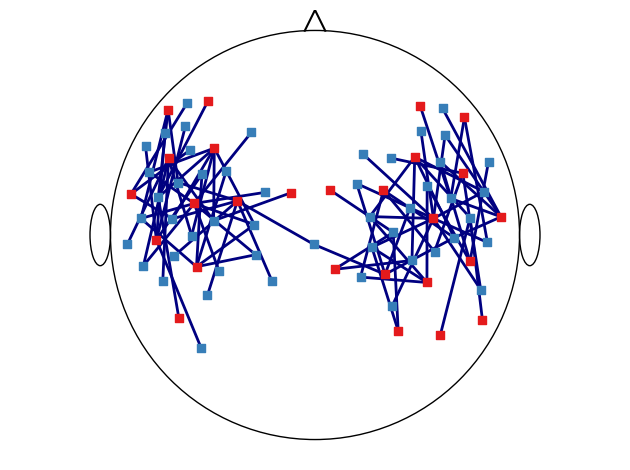

In [200]:
# Approach 3

# Loop over parcels and keep top k channels per parcel
k = 3  # top channels per parcel
channels_per_parcel = []


# for parcel in parcel_dOD_valid.parcel.values:
for parcel in parcel_dOD_valid.sel(channel=chd_mask).parcel.values:
    
    # Get sensitivity for this specific parcel
    # parcel_sens = np.abs(parcel_dOD_valid.sel(parcel=parcel)).mean(dim="wavelength")
    parcel_sens = np.abs(parcel_dOD_valid.sel(parcel=parcel, wavelength=850.0))
    
    # Get top k channels for this parcel (sort descending, take first k)
    top_k = parcel_sens.sortby(parcel_sens, ascending=False).channel.values[:k]
    channels_per_parcel.extend(top_k)

# Get unique channels (same channel can be top-k for multiple parcels)
unique_channels = np.unique(channels_per_parcel)

print(f"Selected {len(unique_channels)} unique channels")
print(f"Coverage: {len(channels_per_parcel)} total assignments (channel-parcel pairs)")

rec['amp_k'] = rec['amp'].sel(channel=unique_channels)
# plot_montage3D(rec['amp_k'], rec.geo3d)
fig, ax = plt.subplots(1, 1)
cedalion.vis.anatomy.scalp_plot(
    rec['amp_k'],
    rec.geo3d,
    np.ones(rec['amp_k'].channel.size),
    ax,
    cmap="jet",
    title="",
    vmin=1,
    vmax=1,
    cb_label="",
    add_colorbar=False,
)
plt.tight_layout()

In [201]:
# min_d, max_d = 1, 6.5
# # distance filtering
# ds_ch, chd_mask = quality.sd_dist(rec["amp_k"], rec.geo3d, [min_d, max_d]*units.cm)
# print(f"Channels before sd dist filtering: {rec['amp_k'].channel.size}")

# ch_in = rec["amp_k"].channel.isin(chd_mask)
# rec["amp_k_dist"] = rec["amp_k"].sel(channel=chd_mask)

# # print number of channels after sd dist filtering
# print(f"Channels after sd dist filtering: {rec['amp_k_dist'].channel.size}")
# # plot_montage3D(rec['amp_k_dist'], rec.geo3d)

# fig, ax = plt.subplots(1, 1)
# cedalion.vis.anatomy.scalp_plot(
#     rec['amp_k_dist'],
#     rec.geo3d,
#     np.ones(rec['amp_k_dist'].channel.size),
#     ax,
#     cmap="jet",
#     title="",
#     vmin=1,
#     vmax=1,
#     cb_label="",
#     add_colorbar=False,
# )
# plt.tight_layout()

In [202]:
rec['amp'].channel.values.size, rec["amp_k"].channel.values.size

(1220, 91)

In [203]:
# Furhter filter out channels based on closest optodes to C3 and C4

# Function to get indices of closest optodes
def get_closest_optodes(optodes, landmark_coord, k=10):
    distances = np.linalg.norm(optodes - landmark_coord, axis=1)
    closest_indices = np.argsort(distances)[:k]
    return list(optodes.label[closest_indices].values)


In [209]:
if DATASET_NAME == "BS_Laura":
    # this is required for BU Data (Laura's)
    T = np.array([
        [-9.57882733e-01, -7.20806358e-03,  6.20193531e-03, 2.21208571e+02],
        [-2.02271710e-02,  6.03819925e-02,  9.94046165e-01, -2.03010603e+01],
        [-8.79481533e-03, -1.02761992e+00,  6.59199998e-02, 2.87749135e+02],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, 1.00000000e+00]])
    
    ninja_aligned = rec.geo3d.points.apply_transform(T)
    geo3d_snapped = head_icbm152.align_and_snap_to_scalp(ninja_aligned)
else:
    geo3d_snapped = head_icbm152.align_and_snap_to_scalp(rec.geo3d)
    
import cedalion.dataclasses as cdc    
geo3d_snapped = geo3d_snapped[geo3d_snapped.type != cdc.PointType.LANDMARK]



# Get closest optodes to C3 and C4
c3_c4_k = 67
closest_c3_indices = get_closest_optodes(geo3d_snapped, head_icbm152.landmarks.sel(label='C3'), k=c3_c4_k)
closest_c4_indices = get_closest_optodes(geo3d_snapped, head_icbm152.landmarks.sel(label='C4'), k=c3_c4_k)
# closest_cz_indices = get_closest_optodes(geo3d_snapped, head.landmarks.sel(label='Cz'), k=30)
#closest_indices = list(set(closest_c3_indices + closest_c4_indices + closest_cz_indices))
closest_indices = list(set(closest_c3_indices + closest_c4_indices))


mask_c3_c4 = rec['amp_k'].source.isin(closest_indices) & rec['amp_k'].detector.isin(closest_indices)
rec['amp_k_dist_c3c4'] = rec['amp_k'].sel(channel=mask_c3_c4)

rec['amp_k'].channel.values.size, rec['amp_k_dist_c3c4'].channel.values.size  

(91, 89)

70

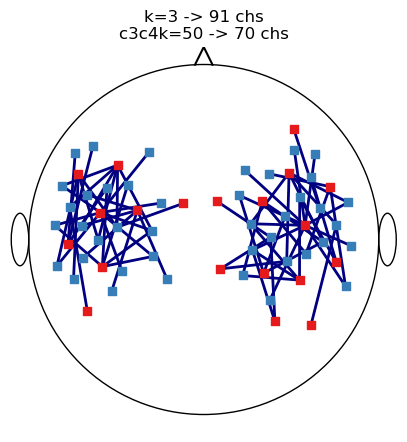

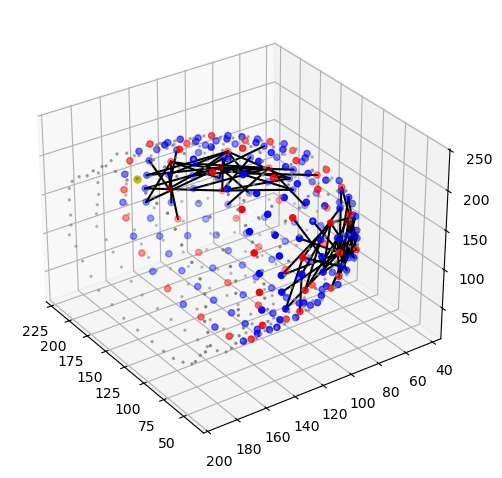

In [197]:
fig, ax = plt.subplots(1, 1)

fig.set_size_inches(5, 5)

plot_montage3D(rec["amp_k_dist_c3c4"], rec.geo3d)

# cedalion.plots.scalp_plot(
import cedalion.vis.anatomy.scalp_plot
cedalion.vis.anatomy.scalp_plot(
    rec['amp_k_dist_c3c4'],
    # geo3d_snapped_ijk,
    rec.geo3d,
    np.ones(rec['amp_k_dist_c3c4'].channel.size),
    ax,
    cmap="jet",
    title=f"k={k} -> {rec['amp_k'].channel.values.size} chs\nc3c4k={c3_c4_k} -> {rec['amp_k_dist_c3c4'].channel.size} chs",
    vmin=1,
    vmax=1,
    # cb_label="",
    add_colorbar=False,
)
rec['amp_k_dist_c3c4'].channel.size

In [198]:
# export numpy array of channel names as np file

np.save(f'datasets/pre_processed/BS_Laura/channel_subset_{DATASET_NAME}_k={k}_c3c4k={c3_c4_k}_dist{max_d}_{rec["amp_k_dist_c3c4"].channel.size}chs.npy', rec["amp_k_dist_c3c4"].channel.values)

In [199]:
channel_subset = np.load(f'datasets/pre_processed/BS_Laura/channel_subset_BS_Laura_k=2_c3c4k=51_dist4.5_50chs.npy', allow_pickle=True)
channel_subset.size

50

In [147]:
rec['amp_k_dist_c3c4'].channel.size

91

In [ ]:
from pathlib import Path
import numpy as np

subset_files = sorted(Path('datasets/pre_processed/BS_Laura').glob('channel_subset_BS_Laura_*.npy'))
assert subset_files, 'No channel subset npy files found.'

for i, f in enumerate(subset_files):
    print(f'[{i}] {f.name}')

reference_idx = 0  # change this index to use a different reference set
reference_file = subset_files[reference_idx]

channel_sets = {
    f.name: set(np.load(f, allow_pickle=True).tolist())
    for f in subset_files
}

ref_set = channel_sets[reference_file.name]
overlap_summary = []
for f in subset_files:
    name = f.name
    s = channel_sets[name]
    overlap = ref_set & s
    overlap_summary.append({
        'file': name,
        'n_channels': len(s),
        'n_overlap_with_ref': len(overlap),
        'pct_ref_covered': 100.0 * len(overlap) / len(ref_set) if ref_set else 0.0,
        'pct_set_overlaps_ref': 100.0 * len(overlap) / len(s) if s else 0.0,
    })

overlap_summary = sorted(overlap_summary, key=lambda x: x['n_overlap_with_ref'], reverse=True)
print(f'\nReference: {reference_file.name} ({len(ref_set)} channels)')
overlap_summary
